<a href="https://colab.research.google.com/github/mhizbulloh/UTS-Citra-Digital-2026-IF24a-Semester-4/blob/main/Jawaban_Nomor_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

👇 Silakan klik tombol 'Choose Files' di bawah untuk memilih gambar dari laptop/device Anda:


Saving TranscodedWallpaper (1) to TranscodedWallpaper (1)

✅ Memproses gambar: TranscodedWallpaper (1)


/tmp/ipykernel_493/2072283236.py:31: RuntimeWarning: overflow encountered in scalar add
  c = 255 / np.log(1 + np.max(img))
/tmp/ipykernel_493/2072283236.py:31: RuntimeWarning: divide by zero encountered in log
  c = 255 / np.log(1 + np.max(img))
/tmp/ipykernel_493/2072283236.py:41: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[0, 1].hist(img.ravel(), 256, [0, 256], color='black')
/tmp/ipykernel_493/2072283236.py:47: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[1, 1].hist(img_negatif.ravel(), 256, [0, 256], color='black')
/tmp/ipykernel_493/2072283236.py:53: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[2, 1].hist

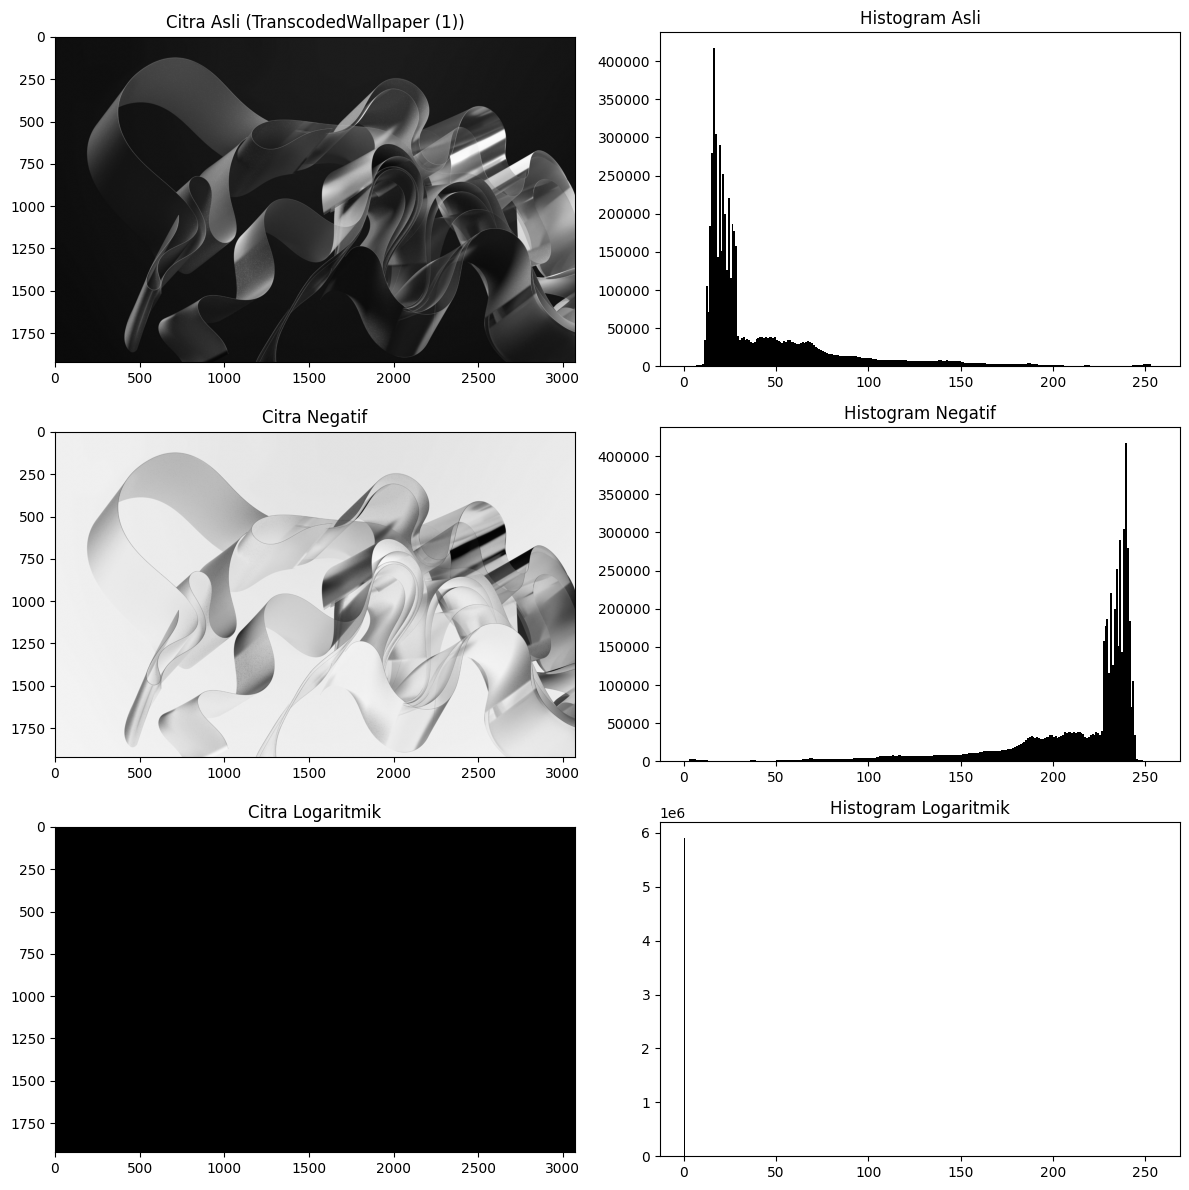


🎉 PROSES SELESAI
1. Gambar dan Histogram telah berhasil ditampilkan.
2. File 'analisa.txt' telah dibuat. Silakan buka menu folder (ikon 📁 di sebelah kiri Colab), lalu download 'analisa.txt' untuk di-upload ke GitHub.


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import os

# --- Langkah 1: Meminta User Mengunggah Foto dari Perangkat ---
print("👇 Silakan klik tombol 'Choose Files' di bawah untuk memilih gambar dari laptop/device Anda:")
uploaded = files.upload()

# Mengecek apakah ada file yang diunggah
if not uploaded:
    print("❌ ERROR: Anda belum memilih gambar apapun.")
else:
    # Mengambil nama file gambar yang baru saja diunggah
    image_path = list(uploaded.keys())[0]
    print(f"\n✅ Memproses gambar: {image_path}")

    # --- Langkah 2: Baca Citra Grayscale ---
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print("❌ ERROR: File yang diupload bukan gambar yang valid atau gagal dibaca.")
    else:
        # --- Langkah 3: Transformasi Negatif ---
        # Rumus: G = 255 - F
        img_negatif = 255 - img

        # --- Langkah 4: Transformasi Logaritmik ---
        # Rumus: G = c * log(1 + F)
        c = 255 / np.log(1 + np.max(img))
        img_log = c * np.log(1 + img.astype(np.float64))
        img_log = np.uint8(img_log)

        # --- Langkah 5: Tampilkan Gambar dan Histogram ---
        fig, axes = plt.subplots(3, 2, figsize=(12, 12))

        # Baris 1: Citra Asli
        axes[0, 0].imshow(img, cmap='gray', vmin=0, vmax=255)
        axes[0, 0].set_title(f'Citra Asli ({image_path})')
        axes[0, 1].hist(img.ravel(), 256, [0, 256], color='black')
        axes[0, 1].set_title('Histogram Asli')

        # Baris 2: Citra Negatif
        axes[1, 0].imshow(img_negatif, cmap='gray', vmin=0, vmax=255)
        axes[1, 0].set_title('Citra Negatif')
        axes[1, 1].hist(img_negatif.ravel(), 256, [0, 256], color='black')
        axes[1, 1].set_title('Histogram Negatif')

        # Baris 3: Citra Logaritmik
        axes[2, 0].imshow(img_log, cmap='gray', vmin=0, vmax=255)
        axes[2, 0].set_title('Citra Logaritmik')
        axes[2, 1].hist(img_log.ravel(), 256, [0, 256], color='black')
        axes[2, 1].set_title('Histogram Logaritmik')

        plt.tight_layout()
        plt.show()

        # --- Langkah 6: Membuat file analisa.txt ---
        teks_analisa = """Analisa Transformasi Citra

1. Perbedaan persebaran nilai keabuan antara ketiga citra:
- Citra Asli: Distribusi nilai piksel murni sesuai input asli.
- Citra Negatif: Histogramnya adalah kebalikan (mirror) dari citra asli. Piksel gelap menjadi terang, dan piksel terang menjadi gelap secara linear.
- Citra Logaritmik: Histogram menunjukkan pergeseran non-linear di mana area gelap pada citra asli "diregangkan" sehingga detail pada area gelap menjadi lebih terlihat, sementara area terang "dimampatkan".

2. Kapan transformasi logaritmik lebih bermanfaat dibanding negatif?
Transformasi logaritmik lebih bermanfaat saat kita berhadapan dengan citra yang memiliki rentang dinamis sangat luas namun detail pentingnya tersembunyi di area yang gelap (intensitas rendah). Contohnya pada citra spektrum Fourier, citra medis rontgen yang gelap, atau foto astronomi. Transformasi ini memperjelas detail gelap tanpa menghilangkan informasi, sedangkan transformasi negatif hanya membalik warna tanpa melakukan kompresi rentang dinamis secara cerdas."""

        with open("analisa.txt", "w") as file:
            file.write(teks_analisa)

        print("\n🎉 PROSES SELESAI")
        print("1. Gambar dan Histogram telah berhasil ditampilkan.")
        print("2. File 'analisa.txt' telah dibuat. Silakan buka menu folder (ikon 📁 di sebelah kiri Colab), lalu download 'analisa.txt' untuk di-upload ke GitHub.")